In [2]:
import numpy as np
import matplotlib.pyplot as plt
import aopy
import os
import pandas as pds
# from db import dbfunctions as db
from ipywidgets import interactive, widgets
# import scipy
import h5py
from tqdm.auto import tqdm 
import seaborn as sn
# import sklearn
# from sklearn.decomposition import PCA, FactorAnalysis
# from itertools import compress
# import multiprocessing as mp
import time
# import math
# from scipy.fft import fft
import glob
# from datetime import date

/home/aolab/miniconda3/envs/np_targeting/lib/python3.9/site-packages/one/alf/files.py:10: FutureWarning: `one.alf.files` will be removed in version 3.0. Use `one.alf.path` instead.
  warnings.warn(


In [350]:
from local_functions import load_yaml_params, get_pseudopopulation_raster
param_filename = 'spatiotemporal_structure_params.yaml'
ds_params, data_paths, save_paths, filenames, postproc_params, uq_params, analysis_params, vis_params, target_colors = load_yaml_params(param_filename)

In [463]:
# load saved decoding accuracy data from both monkeys
behavior_results = {}
lda_results = {}
fr_zscore = {}
lda_metadata = {}
pop_results = {}
for subject in tqdm(ds_params['subjects']):
    behavior_results[subject] = aopy.data.pkl_read(f"{subject}_{filenames['behavior']}", save_paths['postproc_data'])
    lda_results[subject], fr_zscore[subject], lda_metadata[subject] = aopy.data.pkl_read(f"{subject}_{filenames['lda_result']}", save_paths['postproc_data'])
    pop_results[subject] = aopy.data.pkl_read(f"{subject}_{filenames['population_result']}", save_paths['postproc_data'])
    
    _, column_units, _,_,_,_ = aopy.data.base.pkl_read(f"{subject}_{filenames['pseudopopulation']}",  save_paths['postproc_data']) # TOOD move to other files?
    lda_metadata[subject]['site_xpos'] = [np.unique(column_units[icol]['rec_xpos']) for icol in range(len(column_units))]
    lda_metadata[subject]['site_ypos'] = [np.unique(column_units[icol]['rec_ypos']) for icol in range(len(column_units))]

  0%|          | 0/2 [00:00<?, ?it/s]

In [392]:
# Extract useful parameters for all figures
align_events = postproc_params['align_events']
align_event = analysis_params['align_events'][0]
subjects = ds_params['subjects']
ntargets = len(np.unique(fr_zscore[subject]['MOVEMENT ONSET']['target'][0]))
trial_time_axis = lda_metadata[subject]['trial_time_axis']
smooth_time_axis = lda_metadata[subject]['smooth_time_axis']

# Figure 1 Plots

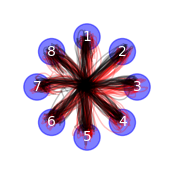

In [509]:
# Plot trajectories from multiple days overlapping
traj_colors = ['red', 'black']
subject = 'beignet'
ndays = 2
fig, ax = plt.subplots(1,1,figsize=(2,2))
for irec in range(ndays):
    traj = [behavior_results[subject]['traj'][irec][:,itraj,:] for itraj in range(behavior_results[subject]['traj'][irec].shape[1])]
    aopy.visualization.plot_trajectories(traj,  ax=ax, color=traj_colors[irec], alpha=0.25, linewidth=1)

aopy.visualization.plot_targets(behavior_results[subject]['traget_locations'], behavior_results[subject]['target_radius'], ax=ax)
ax.set(xlabel='', ylabel='', xlim=(-10,10), ylim=(-10,10), xticks=[], yticks=[])
ax.spines[['bottom', 'left']].set_visible(False)
for itarget in range(behavior_results[subject]['traget_locations'].shape[0]):
    ax.annotate(str(itarget+1), (behavior_results[subject]['traget_locations'][itarget,0], behavior_results[subject]['traget_locations'][itarget,1]), color='white', ha='center', va='center')
ax.set_aspect('equal')
aopy.visualization.savefig(save_paths['figure'][1], f"traj_example.svg")

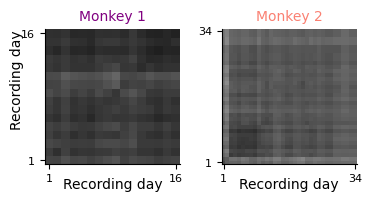

In [513]:
fig, ax = plt.subplots(1,2,figsize=(4,2.5))
for isubject, subject in enumerate(subjects):
    ndays = behavior_results[subject]['traj_corr'].shape[0]
    corr_map = ax[isubject].pcolor(np.mean(behavior_results[subject]['traj_corr'], axis=2), vmin=0.8, vmax=1, cmap='Greys')
    ax[isubject].set_xticks(np.array([0, ndays-1])+0.5, np.array([1, ndays]))
    ax[isubject].set_yticks(np.array([0, ndays-1])+0.5, np.array([1, ndays]))
    ax[isubject].set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])
    ax[isubject].set_aspect('equal')
    ax[isubject].set_xlabel('Recording day', labelpad=-5)
    ax[isubject].grid(False)

# fig.supxlabel('Recording day', x=0.56, y=0.14, fontsize=vis_params['paper_settings']['axes.labelsize'])
fig.supylabel('Recording day', x=0.1, y=0.57, fontsize=vis_params['paper_settings']['axes.labelsize'], ha='center', va='center')     
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][1], f"traj_corr_heatmap.svg")

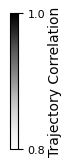

In [508]:
import matplotlib as mpl
cmap = mpl.cm.Grays
norm = mpl.colors.Normalize(vmin=.8, vmax=1)

fig, ax = plt.subplots(figsize=(0.1, 2*.88))  # Adjust size as needed
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('Trajectory Correlation', labelpad=2)
cb.set_ticks([0.8, 1])
aopy.visualization.savefig(save_paths['figure'][1], f"traj_corr_heatmap_colorbar.svg")

# Figure 2 Plots

## (b, c) - PSTH examples

In [451]:
# Set parameters for this figure
recs2plot = [2,15]
unit_ids = [[1,3,4,5], [0,1,7,8]]
subject = 'beignet'

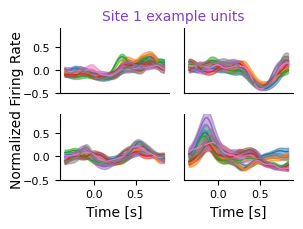

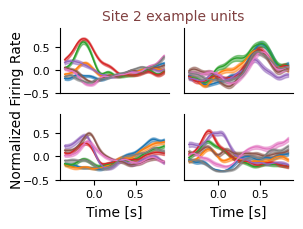

In [452]:
# (b) Show psth for select units
for ii, irec in enumerate(recs2plot):
    temp_fr_data = fr_zscore[subject][align_event]['align_spikes_zscore_smooth'][irec]
    # Create the figure with subplots
    fig, axs = plt.subplots(2, 2, figsize=(3, 2.5))
    axs = axs.flatten()

    # Loop through the units and plot
    for iunit, unitid in enumerate(unit_ids[ii]):
        for itarget in range(ntargets):
            target_mask = fr_zscore[subject][align_event]['target'][irec] == (itarget + 1)

            # Calculate mean and SEM for the firing rate data
            mean_fr_dir = np.mean(temp_fr_data[:, :, target_mask], axis=2)[:, unitid]
            sem_fr_dir = aopy.analysis.calc_sem(temp_fr_data[:, :, target_mask], axis=2)[:, unitid]

            # Plot shaded area for SEM and the mean firing rate
            axs[iunit].fill_between(smooth_time_axis, mean_fr_dir - sem_fr_dir, mean_fr_dir + sem_fr_dir, 
                                    color=target_colors[itarget], alpha=0.5)
            axs[iunit].plot(smooth_time_axis, mean_fr_dir, color=target_colors[itarget], linewidth=1)

            # Set axis labels and titles
            axs[iunit].set(xlabel='Time [s]', ylabel='Normalized Firing Rate', ylim=(-0.5, 0.9))

        # Adjust ticks for specific subplots
        axs[iunit].set(ylabel='')
        if iunit in [0, 1]:
            axs[iunit].set(xticks=[], xlabel='')
        if iunit in [1, 3]:
            axs[iunit].set(yticks=[])

    # Share the y-axis between the left subplots (ax1 and ax3)
    fig.text(0.03, 0.5, 'Normalized Firing Rate', va='center', ha='center', rotation='vertical', fontsize=vis_params['paper_settings']['axes.labelsize'])
    plt.suptitle(f"Site {ii+1} example units", color=vis_params['colors']['example_sites'][ii+1], x=0.55, y=0.9, fontsize=vis_params['paper_settings']['axes.titlesize'])
    fig.tight_layout()
    aopy.visualization.savefig(save_paths['figure'][2], f"fr_psth_{subject}_rec{irec}.svg")

## (d, e) - FR Heatmaps

In [491]:
subject='beignet'
targets_plot = [1,3,5,7]
cb_min, cb_max = -0.5, 0.8

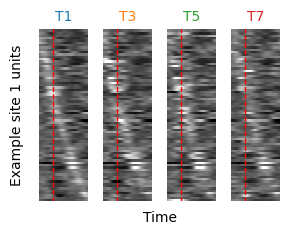

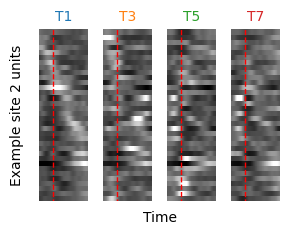

In [494]:
import matplotlib.gridspec as gridspec

# Trial averaged heatmaps of Firing Rate
for ii, irec in enumerate(recs2plot):
    fig, ax = plt.subplots(1,len(targets_plot),figsize=(3,2.5))
    temp_fr_data = fr_zscore[subject][align_event]['align_spikes_zscore_smooth'][irec]
    # unit_order = np.argsort(np.mean(lda_results[subject][align_event]['single_ch_decoding'][irec], axis=1)) # Sort by decoding accuracy
    # unit_order = np.arange(temp_fr_data.shape[1])
    # unit_order = np.flip(np.argsort(np.argmax(np.mean(temp_fr_data,axis=2), axis=0))) # By trial averaged response time idx
    sort_target_mask = fr_zscore[subject][align_event]['target'][irec] == targets_plot[0]
    unit_order = np.flip(np.argsort(np.argmax(np.mean(temp_fr_data[:,:,sort_target_mask],axis=2), axis=0)))
    for itarget, target_idx in enumerate(targets_plot):
        target_mask = fr_zscore[subject][align_event]['target'][irec] == (target_idx)
        axtarg = ax[itarget].pcolor(smooth_time_axis, np.arange(temp_fr_data.shape[1]), np.mean(temp_fr_data[:,:,target_mask], axis=2)[:,unit_order].T, cmap='gray')
        ax[itarget].set_xticks([]), ax[itarget].set_yticks([])
        ax[itarget].plot([smooth_time_axis[np.where(smooth_time_axis>=0)[0][0]], smooth_time_axis[np.where(smooth_time_axis>=0)[0][0]]], [-1,temp_fr_data.shape[1]], 'r--', linewidth=1)
        ax[itarget].set(ylim=(-.5,temp_fr_data.shape[1]-.5))
        ax[itarget].set_title(f"T{target_idx}", color=target_colors[itarget])
        ax[itarget].spines['left'].set_visible(False), ax[itarget].spines['bottom'].set_visible(False)
        axtarg.set_clim([-.5,.8])
    fig.supxlabel('Time', x=0.55,y=0.08, fontsize=vis_params['paper_settings']['axes.labelsize']), fig.supylabel(f'Example site {ii+1} units', x=0.05, y=0.52, fontsize=vis_params['paper_settings']['axes.labelsize'])
    plt.subplots_adjust(wspace=0.2, hspace=0.1)
    fig.tight_layout()
    aopy.visualization.savefig(save_paths['figure'][2], f"fr_heatmaps_{subject}_rec{irec}.png")

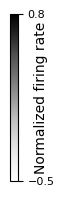

In [265]:
import matplotlib as mpl
cmap = mpl.cm.Grays
norm = mpl.colors.Normalize(vmin=cb_min, vmax=cb_max)

fig, ax = plt.subplots(figsize=(0.1, 2.5*0.87))  # Adjust size as needed
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('Normalized firing rate', labelpad=-15)
cb.set_ticks([cb_min, cb_max])
aopy.visualization.savefig(save_paths['figure'][2], f"fr_heatmaps_colorbar.svg")

## (f,g) Single unit decoding

In [40]:
vis_params['colors']

{'affi': 'mediumblue',
 'beignet': 'purple',
 'example_sites': {1: [0.5, 0.25, 0.75], 2: [0.5, 0.25, 0.25]}}

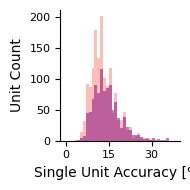

In [47]:
fig, ax = plt.subplots(1,1,figsize=(2,2))
for subject in np.flip(subjects):    
    su_decoding = 100*lda_results[subject][align_event]['single_ch_decoding_all']
    ax.hist(su_decoding, bins=np.arange(0,np.max(su_decoding),1), color=vis_params['colors'][subject], alpha = 0.5)
    ax.set(xlabel='Single Unit Accuracy [%]', ylabel='Unit Count')
    ax.set_xticks([0,15,30])
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][2], f"su_decoding_hist.svg")


## (h, i) - Depth decoding

In [45]:
subjects = ds_params['subjects']

ndepths = int(np.ceil((analysis_params['depth_max'] - analysis_params['depth_range'])/analysis_params['depth_step']))
depth_ranges = [(idepth*analysis_params['depth_step'], (idepth*analysis_params['depth_step'])+analysis_params['depth_range']) for idepth in range(ndepths)]
depth_axis_plt = np.mean(depth_ranges, axis=1)/1000 # convert to mm

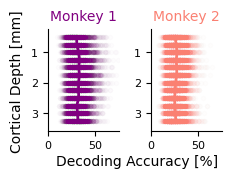

In [475]:
fig, ax = plt.subplots(1,2,figsize=(2.5,2))
for isubject, subject in enumerate(subjects):
    depth_scores = np.array([np.mean(lda_results[subject][align_event]['pseudopopulations']['depth_scores'][idepth], axis=1) for idepth in range(ndepths)])
    depth_scores_mean = np.array([np.mean(lda_results[subject][align_event]['pseudopopulations']['depth_scores'][idepth]) for idepth in range(ndepths)])
    
    ax[isubject].plot(100*depth_scores, depth_axis_plt, '.',color=vis_params['colors'][subject], alpha=0.01)
    ax[isubject].plot(100*depth_scores_mean, depth_axis_plt,color=vis_params['colors'][subject])
    ax[isubject].set(xlim=(0,75), ylim=(analysis_params['depth_step']/1000,(analysis_params['depth_max']-analysis_params['depth_step'])/1000))
    ax[isubject].set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])
    ax[isubject].invert_yaxis()
    
fig.supxlabel('Decoding Accuracy [%]', x=0.6, y=0.13, fontsize=vis_params['paper_settings']['axes.labelsize'])
fig.supylabel('Cortical Depth [mm]', x=0.12, y=0.57, fontsize=vis_params['paper_settings']['axes.labelsize'], ha='center', va='center') 
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][2], f'lda_depth.svg')
aopy.visualization.savefig(save_paths['figure'][2], f'lda_depth.png')

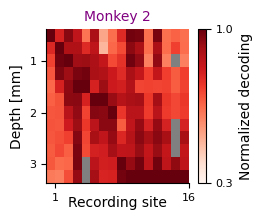

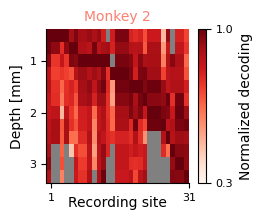

In [478]:
from matplotlib.colors import ListedColormap
for subject in subjects:
    recording_sites = lda_metadata[subject]['recording_site']
    depth_scores_by_site = []
    for isite, site in enumerate(recording_sites):
        temp_depth_scores = np.array([lda_results[subject][align_event]['pseudopopulations']['depth_scores_by_site'][site][igroup] for igroup in range(ndepths)])
        # depth_score_max = [np.mean(temp_depth_scores[idepth,:]) for idepth in range(temp_depth_scores.shape[0])]
        
        if np.sum(~np.isnan(np.mean(temp_depth_scores,axis=1))) > analysis_params['min_site_depths']:
            depth_scores_by_site.append(np.mean(temp_depth_scores,axis=1))    
    
        # Normalize the depth scores
    normalized_depth = (np.array(depth_scores_by_site)[:,:] / np.nanmax(np.array(depth_scores_by_site)[:,:], axis=1)[:, None])
    
    # Replace NaNs with a specific value (e.g., -1 or 0)
    normalized_depth_with_nan = np.nan_to_num(normalized_depth, nan=-1)  # NaNs become -1
    
    # Create a custom colormap where -1 (NaN) is gray, and the rest is a red colormap
    cmap = plt.cm.Reds
    cmap = ListedColormap(cmap(np.linspace(0, 1, 256)))
    cmap.set_under('gray')  # Values less than the minimum (e.g., -1) will be shown as gray
    
    fig, ax = plt.subplots(1,1,figsize=(2.3,2))
    normalized_depth = (np.array(depth_scores_by_site)[:,:]/np.nanmax(np.array(depth_scores_by_site)[:,:], axis=1)[:,None])
    peak_dec_depth_idx_sort = np.argsort(np.nanargmax(normalized_depth, axis=1))
    
    im = ax.pcolor(np.arange(len(depth_scores_by_site))+.5, depth_axis_plt,  normalized_depth_with_nan[peak_dec_depth_idx_sort,:].T, cmap=cmap)
    cb = plt.colorbar(im, label='Normalized decoding')
    im.set_clim(0.3,1)
    cb.set_ticks(im.get_clim())
    ax.set_xlabel('Recording site', labelpad=-5), ax.set_ylabel('Depth [mm]')
    ax.set_yticks([1,2,3], [1,2,3]), ax.set_xticks((1, np.array(depth_scores_by_site).shape[0]))
    ax.set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])
    ax.invert_yaxis()
    aopy.visualization.savefig(save_paths['figure'][2], f'{subject}_lda_depth_by_site.svg')

## (j) - Column decoding

/home/aolab/miniconda3/envs/np_targeting/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/aolab/miniconda3/envs/np_targeting/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


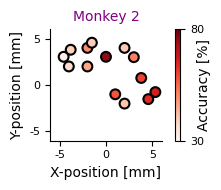

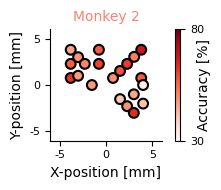

In [479]:
## Plot spatial map of decoding
for subject in subjects:
    fig, ax = plt.subplots(1,1,figsize=(3,2))
    nsites = len(lda_results[subject][align_event]['pseudopopulations']['column_scores'])
    colors = [100*np.mean(lda_results[subject][align_event]['pseudopopulations']['column_scores'][isite]) for isite in range(nsites)]
    dec_map = ax.scatter(lda_metadata[subject]['site_xpos'], lda_metadata[subject]['site_ypos'], s=50, c=colors, cmap='Reds', vmin=30, vmax=80, edgecolor='black', linewidths=1.5)
    cb = plt.colorbar(dec_map)
    cb.set_ticks([30,80]), cb.set_label('Accuracy [%]', labelpad=-5)
    ax.set(xlim=(-6,6), ylim=(-6,6))
    ax.set_aspect('equal')
    ax.set_xlabel('X-position [mm]'), ax.set_ylabel('Y-position [mm]')
    ax.set_xticks([-5,0,5], [-5,0,5]), ax.set_yticks([-5,0,5], [-5,0,5])
    ax.set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])

    fig.tight_layout()
    aopy.visualization.savefig(save_paths['figure'][2], f'{subject}_lda_column.svg')

# Figure 3 Plots

## (b) Example aligned dynamics

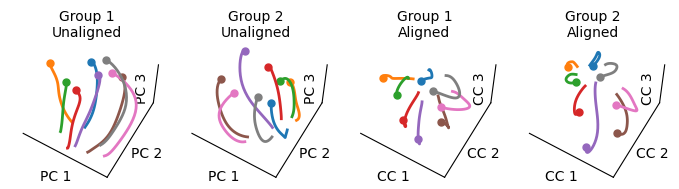

In [528]:
# Example aligned dynamics
from mpl_toolkits.mplot3d import Axes3D
subject = 'beignet'
# align_event = align_events[-1]
viewpoint = (240, 60)
# Create a figure with two subplots
fig = plt.figure(figsize=(6.9, 2))

# First subplot for PCA 1
ax1 = fig.add_subplot(141, projection='3d')
for itarget in range(ntargets):   
    ax1.plot(pop_results[subject][align_event]['example']['La'][:,0,itarget], pop_results[subject][align_event]['example']['La'][:, 1,itarget], pop_results[subject][align_event]['example']['La'][:,2,itarget], color=target_colors[itarget])
    ax1.plot(pop_results[subject][align_event]['example']['La'][0,0,itarget], pop_results[subject][align_event]['example']['La'][0,1,itarget], pop_results[subject][align_event]['example']['La'][0,2,itarget], '.', markersize=10, color=target_colors[itarget])
ax1.view_init(viewpoint[0],viewpoint[1]), ax1.grid(False), ax1.set(xticks=[], yticks=[], zticks=[])
ax1.set_title('Group 1\nUnaligned', y=0.95)
ax1.set_xlabel('PC 1', labelpad=-10),ax1.set_ylabel('PC 2', labelpad=-10), ax1.set_zlabel('PC 3', labelpad=-27, rotation=90)
ax1.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)), ax1.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)), ax1.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    
# Second subplot for PCA2
ax2 = fig.add_subplot(142, projection='3d')
for itarget in range(ntargets):
    ax2.plot(pop_results[subject][align_event]['example']['Lb'][:,0,itarget], pop_results[subject][align_event]['example']['Lb'][:,1,itarget], pop_results[subject][align_event]['example']['Lb'][:,2,itarget], color=target_colors[itarget])
    ax2.plot(pop_results[subject][align_event]['example']['Lb'][0,0,itarget], pop_results[subject][align_event]['example']['Lb'][0,1,itarget], pop_results[subject][align_event]['example']['Lb'][0,2,itarget], '.', markersize=10, color=target_colors[itarget])
ax2.view_init(viewpoint[0],viewpoint[1]), ax2.grid(False), ax2.set(xticks=[], yticks=[], zticks=[])
ax2.set_title('Group 2\nUnaligned', y=0.95)
ax2.set_xlabel('PC 1', labelpad=-10),ax2.set_ylabel('PC 2', labelpad=-10), ax2.set_zlabel('PC 3', labelpad=-27, rotation=90)
ax2.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)), ax2.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)), ax2.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))


# First subplot for CCA1
ax3 = fig.add_subplot(143, projection='3d')
for itarget in range(ntargets):
    ax3.plot(pop_results[subject][align_event]['example']['CCAa'][:,0,itarget], pop_results[subject][align_event]['example']['CCAa'][:,1,itarget], pop_results[subject][align_event]['example']['CCAa'][:,2,itarget], color=target_colors[itarget])
    ax3.plot(pop_results[subject][align_event]['example']['CCAa'][0,0,itarget], pop_results[subject][align_event]['example']['CCAa'][0,1,itarget], pop_results[subject][align_event]['example']['CCAa'][0,2,itarget], '.', markersize=10,color=target_colors[itarget])
ax3.view_init(viewpoint[0],viewpoint[1]), ax3.grid(False), ax3.set(xticks=[], yticks=[], zticks=[])
ax3.set_title('Group 1\nAligned', y=0.95)
ax3.set_xlabel('CC 1', labelpad=-10), ax3.set_ylabel('CC 2', labelpad=-10), ax3.set_zlabel('CC 3', labelpad=-27, rotation=90)
ax3.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)), ax3.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)), ax3.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    
# Second subplot for CCA2
ax4 = fig.add_subplot(144, projection='3d')
for itarget in range(ntargets):
    ax4.plot(pop_results[subject][align_event]['example']['CCAb'][:,0,itarget], pop_results[subject][align_event]['example']['CCAb'][:,1,itarget], pop_results[subject][align_event]['example']['CCAb'][:,2,itarget], color=target_colors[itarget])
    ax4.plot(pop_results[subject][align_event]['example']['CCAb'][0,0,itarget], pop_results[subject][align_event]['example']['CCAb'][0,1,itarget], pop_results[subject][align_event]['example']['CCAb'][0,2,itarget],'.', markersize=10, color=target_colors[itarget])
ax4.view_init(viewpoint[0],viewpoint[1]), ax4.grid(False), ax4.set(xticks=[], yticks=[], zticks=[])
ax4.set_title('Group 2\nAligned', y=0.95)
ax4.set_xlabel('CC 1', labelpad=-10), ax4.set_ylabel('CC 2', labelpad=-10), ax4.set_zlabel('CC 3', labelpad=-27, rotation=90)
ax4.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)), ax4.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0)), ax4.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

plt.tight_layout()  # Adjust subplots to fit in the figure area
aopy.visualization.savefig(save_paths['figure'][3], f'{subject}_cca_example.svg')

In [518]:
pop_results[subject][align_event]['example']['CCAa'][0,0,itarget]

-0.7389267610579818

## (d) Cortical surface distance

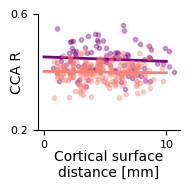

In [63]:
# align_event = align_events[-1]
# subject = 'beignet'
fig, ax = plt.subplots(1,1,figsize=(2,2))
for subject in subjects:
    pos_diff = pop_results[subject][align_event]['column']['pos_diff']
    cca = np.mean(pop_results[subject][align_event]['column']['cca'][:,:,:analysis_params['nmodes_avg_cca']],axis=2)
    nan_mask = np.logical_and(~np.isnan(pos_diff.flatten()), ~np.isnan(cca.flatten()))
    fit, fitscore, pcc, pval, regfit = aopy.analysis.base.linear_fit_analysis2D(pos_diff.flatten()[nan_mask], cca.flatten()[nan_mask])
    intercept, slope = regfit.intercept_, regfit.coef_[0]
    ax.plot(pos_diff, cca,'.', color=vis_params['colors'][subject], alpha=0.2)
    ax.plot([0,10], [intercept, slope*10 + intercept], color=vis_params['colors'][subject])
ax.set_xticks([0, 10]), ax.set_ylim(0.2,0.6), ax.set_yticks([0.2,0.6])
ax.set_xlabel('Cortical surface\ndistance [mm]', labelpad=0), ax.set_ylabel('CCA R',labelpad=-10)
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][3], f'cca_dpos.svg')

## Column vs. column CCA hist

In [530]:
cb_min, cb_max = 0.3, 0.6

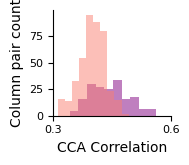

In [538]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,1, figsize=(2,1.75))
for isubject, subject in enumerate(subjects):
    input_data = np.mean(pop_results[subject][align_event]['column']['cca'][:,:,:analysis_params['nmodes_avg_cca']], axis=2)
    input_data[np.diag_indices(input_data.shape[0])] = np.nan
    ax.hist(input_data.flatten(), color=vis_params['colors'][subject], alpha=0.5)
ax.set_xlim([cb_min, cb_max])
ax.set_xticks([cb_min, cb_max])
ax.set_xlabel('CCA Correlation'), ax.set_ylabel('Column pair count')

fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][3], f'cca_hist.svg')

## (f) Rostral-caudal axis organization

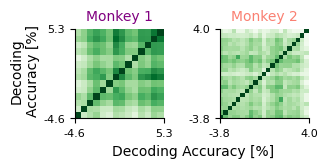

In [449]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,2, figsize=(3.5,2.5))
for isubject, subject in enumerate(subjects):
    nsites = pop_results[subject][align_event]['column']['cca_rc_ordered'].shape[0]
    im = ax[isubject].pcolor(pop_results[subject][align_event]['column']['cca_rc_ordered'], cmap='Greens')
    im.set_clim(cb_min,cb_max)
    ax[isubject].set_xticks((0,nsites), (np.round(np.min(pop_results[subject][align_event]['column']['rc_order']), 1), np.round(np.max(pop_results[subject][align_event]['column']['rc_order']), 1)))
    ax[isubject].set_yticks((0,nsites), (np.round(np.min(pop_results[subject][align_event]['column']['rc_order']), 1), np.round(np.max(pop_results[subject][align_event]['column']['rc_order']), 1)))
    ax[isubject].set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])
    ax[isubject].set_aspect('equal')
fig.supxlabel('Decoding Accuracy [%]', x=0.6, y=0.22, fontsize=vis_params['paper_settings']['axes.labelsize'])
fig.supylabel('Decoding\nAccuracy [%]', x=0.12, y=0.57, fontsize=vis_params['paper_settings']['axes.labelsize'], ha='center', va='center') 
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][3], f'cca_rcpos.svg')

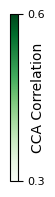

In [133]:
import matplotlib as mpl
cmap = mpl.cm.Greens
norm = mpl.colors.Normalize(vmin=cb_min, vmax=cb_max)

fig, ax = plt.subplots(figsize=(0.1, 2.5*0.87))  # Adjust size as needed
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('CCA Correlation', labelpad=-10)
cb.set_ticks([cb_min, cb_max])
aopy.visualization.savefig(save_paths['figure'][3], f"cca_colorbar.svg")

## (g) Rostral-caudal neighboring CCA

R: 0.622 0.0008017056154426315
R: 0.183 0.05276540172360357


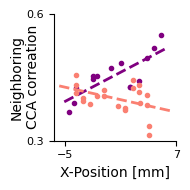

In [134]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,1,figsize=(2,2))
for subject in subjects:
    ax.plot(pop_results[subject][align_event]['column']['rc_order'], pop_results[subject][align_event]['column']['rc_neighboring_cca'],'.', color=vis_params['colors'][subject])
    fit, fitscore, pcc, pval, regfit = aopy.analysis.base.linear_fit_analysis2D(pop_results[subject][align_event]['column']['rc_order'], pop_results[subject][align_event]['column']['rc_neighboring_cca'])
    print(f"R: {np.round(fitscore,3)}", pval)
    intercept, slope = regfit.intercept_, regfit.coef_[0]
    ax.plot([ax.get_xlim()[0],ax.get_xlim()[1]], [(slope*ax.get_xlim()[0])+intercept, (slope*ax.get_xlim()[1])+intercept], '--', color=vis_params['colors'][subject])
    
ax.set_xticks([-5, 7]), ax.set_yticks([cb_min, cb_max])
ax.set(xlabel='X-Position [mm]')
ax.set_ylabel('Neighboring\nCCA correation', labelpad=-10)
# ax.annotate(f'$R^2$={np.round(fitscore,2)}',(0,0.35), color='C0')

fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][3], f'cca_rcpos_neighboring.svg')

## (i) Decoding organization

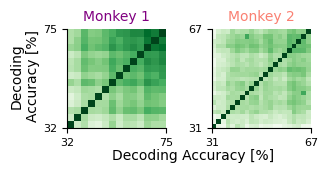

In [448]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,2, figsize=(3.5,2.5))
for isubject, subject in enumerate(subjects):
    nsites = pop_results[subject][align_event]['column']['cca_acc_ordered'].shape[0]
    im = ax[isubject].pcolor(pop_results[subject][align_event]['column']['cca_acc_ordered'], cmap='Greens')
    im.set_clim(cb_min,cb_max)
    ax[isubject].set_xticks((0,nsites), (int(np.min(pop_results[subject][align_event]['column']['acc_ordered'])), int(np.max(pop_results[subject][align_event]['column']['acc_ordered']))))
    ax[isubject].set_yticks((0,nsites), (int(np.min(pop_results[subject][align_event]['column']['acc_ordered'])), int(np.max(pop_results[subject][align_event]['column']['acc_ordered']))))
    # ax[isubject].set_xlabel('Decoding\nAccuracy [%]', labelpad=-5), ax[isubject].set_ylabel('Decoding\nAccuracy [%]', labelpad=-2)
    ax[isubject].set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])
    ax[isubject].set_aspect('equal')
fig.supxlabel('Decoding Accuracy [%]', x=0.6, y=0.22, fontsize=vis_params['paper_settings']['axes.labelsize'])
fig.supylabel('Decoding\nAccuracy [%]', x=0.12, y=0.57, fontsize=vis_params['paper_settings']['axes.labelsize'], ha='center', va='center') 
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][3], f'cca_accs.svg')

## (j) Decoding neighboring CCA

{'beignet': 0.9570450725414277, 'affi': 0.7887460581786101}


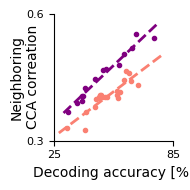

In [532]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,1,figsize=(2,2))
fitscores = {}
for subject in subjects:
    ax.plot(pop_results[subject][align_event]['column']['acc_ordered'], pop_results[subject][align_event]['column']['acc_neighboring_cca'],'.', color=vis_params['colors'][subject])
    fit, fitscore, pcc, pval, regfit = aopy.analysis.base.linear_fit_analysis2D(pop_results[subject][align_event]['column']['acc_ordered'], pop_results[subject][align_event]['column']['acc_neighboring_cca'])
    intercept, slope = regfit.intercept_, regfit.coef_[0]
    ax.plot([ax.get_xlim()[0],ax.get_xlim()[1]], [(slope*ax.get_xlim()[0])+intercept, (slope*ax.get_xlim()[1])+intercept], '--', color=vis_params['colors'][subject])
    fitscores[subject] = fitscore

ax.set_xticks([25, 85]), ax.set_yticks([cb_min, cb_max])
ax.set(xlabel='Decoding accuracy [%]')
ax.set_ylabel('Neighboring\nCCA correation', labelpad=-10)
# ax.annotate(f'$R^2$={np.round(fitscore,2)}',(45,0.35), color='k')
print(fitscores)
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][3], f'cca_accs_neighboring.svg')

## (k) Rostral-caudal vs. decoding organization

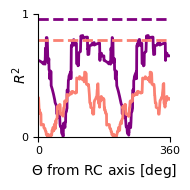

In [69]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,1,figsize=(2,2))
for subject in subjects:
    ax.plot(np.rad2deg(pop_results[subject][align_event]['column']['random_angles'][np.argsort(pop_results[subject][align_event]['column']['random_angles'])]), pop_results[subject][align_event]['column']['random_r2'] [np.argsort(pop_results[subject][align_event]['column']['random_angles'] )], color=vis_params['colors'][subject])
    ax.plot([0,360], [fitscores[subject], fitscores[subject]], '--', color=vis_params['colors'][subject])
    
ax.set(xlim=(0,360), ylim=(0,1))
ax.set_xticks([0, 360]), ax.set_yticks([0, 1])
ax.set_xlabel('$\Theta$ from RC axis [deg]'), ax.set_ylabel('$R^2$', labelpad=-5)
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][3], f'cca_rcpos_acc_neighboring.svg')

# Figure 4 Plots

In [303]:
cb_min4, cb_max4 = 0.3, 1

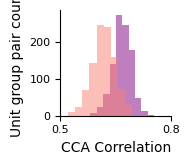

In [304]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,1, figsize=(2,1.75))
for isubject, subject in enumerate(subjects):
    input_data = np.mean(pop_results[subject][align_event]['random']['cca'][:,:analysis_params['nmodes_avg_cca']], axis=1)
    # input_data[np.diag_indices(input_data.shape[0])] = np.nan
    ax.hist(input_data.flatten(), color=vis_params['colors'][subject], alpha=0.5)
ax.set_xlim([0.5, 0.8])
ax.set_xticks([0.5, 0.8])
ax.set_xlabel('CCA Correlation'), ax.set_ylabel('Unit group pair count')
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][4], f'random_cca_hist.svg')

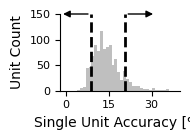

In [581]:
fig, ax = plt.subplots(1,1,figsize=(2,1.5))
subject = 'beignet'
su_decoding = 100*lda_results[subject][align_event]['single_ch_decoding_all']
ax.hist(su_decoding, bins=np.arange(0,np.max(su_decoding),1), color='Gray', alpha = 0.5)
lowthresh, highthresh = 100*pop_results[subject][align_event]['low_v_high']['low_dec_thresh'], 100*pop_results[subject][align_event]['low_v_high']['high_dec_thresh']
ax.set_ylim([0,150])
ax.plot([lowthresh,lowthresh], ax.get_ylim(), 'k--')
ax.plot([highthresh,highthresh], ax.get_ylim(), 'k--')
arrow_length = lowthresh - ax.get_xlim()[0]
ax.annotate('', xy=(ax.get_xlim()[0], ax.get_ylim()[1]), xytext=(lowthresh, ax.get_ylim()[1]), 
            arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='-|>', lw=1))
ax.annotate('', xy=(highthresh+arrow_length, ax.get_ylim()[1]), xytext=(highthresh, ax.get_ylim()[1]), 
            arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='-|>', lw=1))

ax.set(xlabel='Single Unit Accuracy [%]', ylabel='Unit Count')
ax.set_xticks([0,15,30])
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][4], f"su_decoding_hist.svg")


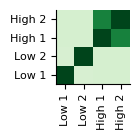

In [573]:
subject = 'beignet'
# align_event = align_events[-1]
    
fig, ax = plt.subplots(1,1,figsize=(1.5,1.5))
labels = pop_results[subject][align_event]['low_v_high']['Ln_split_labels']
im_pp = ax.pcolor(np.arange(len(labels)), np.arange(len(labels)), np.mean(pop_results[subject][align_event]['low_v_high']['cca'][:,:,:analysis_params['nmodes_avg_cca']], axis=(2,3)), cmap='Greens', vmin=cb_min4, vmax=cb_max4)
ax.set_xticks(np.arange(len(labels)), labels, rotation=90),ax.set_yticks(np.arange(len(labels)), labels, rotation=0)
ax.set_aspect('equal')
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][4], f'cca_high_low_square.svg')

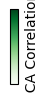

In [584]:
import matplotlib as mpl
cmap = mpl.cm.Greens
norm = mpl.colors.Normalize(vmin=cb_min4, vmax=cb_max4)

fig, ax = plt.subplots(figsize=(0.1, .97))  # Adjust size as needed
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('CCA Correlation', labelpad=5, fontsize=vis_params['paper_settings']['axes.labelsize'])
cb.set_ticks([])
aopy.visualization.savefig(save_paths['figure'][4], f"cca_high_low_colorbar.svg")

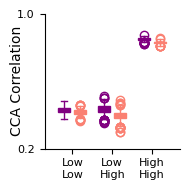

In [307]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,1,figsize=(2,2))

xpos = np.array([0, 1,2])
# colors= ['C0', 'C1']
for isubject, subject in enumerate(subjects):
    plot_list = []
    plot_list.append(np.mean(pop_results[subject][align_event]['low_v_high']['cca'][:,:,:analysis_params['nmodes_avg_cca']], axis=2)[0,1,:].flatten()) # low vs. Low
    plot_list.append(np.mean(pop_results[subject][align_event]['low_v_high']['cca'][:,:,:analysis_params['nmodes_avg_cca']], axis=2)[[0,1],[2,3],:].flatten()) # low vs. High
    plot_list.append(np.mean(pop_results[subject][align_event]['low_v_high']['cca'][:,:,:analysis_params['nmodes_avg_cca']], axis=2)[2,3,:].flatten()) # high vs. high
    aopy.visualization.plot_boxplots(plot_list, xpos+(isubject*0.4), trendline=False, facecolor=vis_params['colors'][subject], linecolor=vis_params['colors'][subject], ax=ax, box_width=0.3, label_xticks=False)
ax.set_ylabel('CCA Correlation', labelpad=-5), ax.set_ylim(cb_min4-.1, cb_max4)
ax.set_xticks([0.2, 1.2, 2.2], ['Low\nLow', 'Low\nHigh', 'High\nHigh'])
ax.set_yticks([cb_min4-.1, cb_max4])
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][4], f'cca_high_low_boxplot.svg')

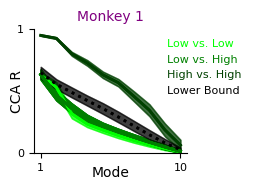

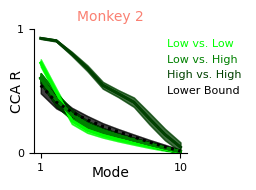

In [591]:
for isubject, subject in enumerate(subjects):
    fig, ax = plt.subplots(1,1,figsize=(2.5,2))
    colors = [[0,1,0], [0,.5,0], [0,.25,0], 'k']
    ax.plot([], color=colors[0]) # Plot no show lone for legend
    ax.plot([], color=colors[1]) # Plot no show lone for legend
    ax.plot([], color=colors[2]) # Plot no show lone for legend
    ax.plot([], 'k') # Plot no show lone for legend
    labels = pop_results[subject][align_event]['low_v_high']['Ln_split_labels']
    for itrain in range(len(labels)):
        for itest in range(len(labels)):
            if itrain != itest:
                mean_value = np.mean(pop_results[subject][align_event]['low_v_high']['cca'][itrain,itest,:,:], axis=1) 
                std_value = np.std(pop_results[subject][align_event]['low_v_high']['cca'][itrain,itest,:,:], axis=1) 
                mean_value_intertrial = np.mean(pop_results[subject][align_event]['low_v_high']['cca_intertrial'][itrain,itest,:], axis=1) 
                std_value_intertrial = np.std(pop_results[subject][align_event]['low_v_high']['cca_intertrial'][itrain,itest,:], axis=1) 
                if itrain < 2 and itest < 2: 
                    ax.plot(mean_value,color=[0,1,0])
                    ax.fill_between(np.arange(analysis_params['npcs']), mean_value-std_value, mean_value+std_value, alpha=0.5, color=[0,1,0])
                elif (itrain < 2 & itest >= 2) or (itrain >= 2 & itest < 2):
                    ax.plot(mean_value,color=[0,.5,0])
                    ax.fill_between(np.arange(analysis_params['npcs']), mean_value-std_value, mean_value+std_value, alpha=0.5, color=[0,.5,0])
                elif itrain >= 2 and itest >= 2:
                    ax.plot(mean_value,color=[0,.25,0], label='High vs. High')
                    ax.fill_between(np.arange(analysis_params['npcs']), mean_value-std_value, mean_value+std_value, alpha=0.5, color=[0,.25,0])
                    ax.fill_between(np.arange(analysis_params['npcs']), mean_value_intertrial-std_value_intertrial, mean_value_intertrial+std_value_intertrial, alpha=0.5, color='black')
                    ax.plot(mean_value_intertrial, 'k:')
    legend = ax.legend(['Low vs. Low','Low vs. High', 'High vs. High', 'Lower Bound'],loc='upper left', bbox_to_anchor=(.6,1), fontsize=vis_params['paper_settings']['xtick.labelsize'])
    [text.set_color(colors[itext]) for itext, text in enumerate(legend.get_texts())]
    [line.set_linewidth(0) for line in legend.get_lines()]
    legend.get_frame().set_visible(False)
    ax.set(ylim=(0,1))
    ax.set_xlabel('Mode', labelpad=-5)
    ax.set_ylabel('CCA R', labelpad=-5)
    ax.set_xticks([0,9], [1,10])
    ax.set_yticks([0,1], [0,1])
    ax.set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])
    fig.tight_layout()
    aopy.visualization.savefig(save_paths['figure'][4], f'cca_high_low_modes_{subject}.svg')

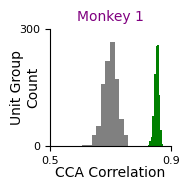

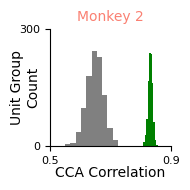

In [589]:
for isubject, subject in enumerate(subjects):
    fig, ax = plt.subplots(1,1,figsize=(2,2))
    ax.hist(np.mean(pop_results[subject][align_event]['any_v_high']['cca'][1,0,:analysis_params['nmodes_avg_cca'],:], axis=0).flatten(), color='Gray')
    ax.hist(np.mean(pop_results[subject][align_event]['low_v_high']['cca'][3,2,:analysis_params['nmodes_avg_cca'],:],axis=0).flatten(), color='Green')
    ax.set_xlabel('CCA Correlation', labelpad=0), ax.set_xlim(.5, 0.9)
    ax.set_xticks([0.5,0.9])
    ax.set_ylabel('Unit Group\nCount', labelpad=-15), ax.set_ylim([0,300]), ax.set_yticks([0,300])
    ax.set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])
    fig.tight_layout()
    aopy.visualization.savefig(save_paths['figure'][4], f'cca_high_any_hist_{subject}.svg')

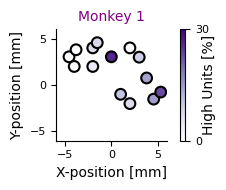

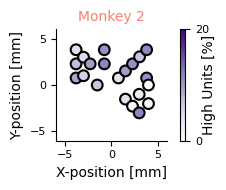

In [539]:
for isubject, subject in enumerate(subjects):
    unique_pos = np.unique(pop_results[subject][align_event]['unit_pos'], axis=0)
    high_mod_unit_pos = pop_results[subject][align_event]['unit_pos'][lda_results[subject][align_event]['single_ch_decoding_all'] >= pop_results[subject][align_event]['low_v_high']['high_dec_thresh'],:]
    nunits_per_pos = np.zeros(unique_pos.shape[0])*np.nan
    total_units_per_pos = np.zeros(unique_pos.shape[0])*np.nan
    
    for ipos in range(unique_pos.shape[0]):
        nunits_per_pos[ipos] = np.sum(np.logical_and(high_mod_unit_pos[:,0] == unique_pos[ipos,0], high_mod_unit_pos[:,1] == unique_pos[ipos,1]))
        total_units_per_pos[ipos] = np.sum(np.logical_and(pop_results[subject][align_event]['unit_pos'][:,0] == unique_pos[ipos,0], pop_results[subject][align_event]['unit_pos'][:,1] == unique_pos[ipos,1]))
        
    fig, ax = plt.subplots(1,1,figsize=(3,2))
    high_unit_prop = (nunits_per_pos/total_units_per_pos)*100
    enough_unit_mask = total_units_per_pos >= analysis_params['nunits_column']
    dec_map = ax.scatter(unique_pos[enough_unit_mask,0], unique_pos[enough_unit_mask,1], s=60, c=high_unit_prop[enough_unit_mask], cmap='Purples', edgecolor='black', linewidths=1.5)
    ax.set(xlim=(-6,6), ylim=(-6,6), xlabel='X-position [mm]', ylabel='Y-position [mm]')
    ax.set_aspect('equal')
    ax.set_xticks([-5,0,5]), ax.set_yticks([-5,0,5])
    ax.set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])

    cb = plt.colorbar(dec_map)
    cb.set_label('High Units [%]',labelpad=-5)
    if subject == 'beignet':
        dec_map.set_clim([0,30])
        cb.set_ticks([0,30])
    elif subject == 'affi':
        dec_map.set_clim([0,20])
        cb.set_ticks([0,20])
    
    fig.tight_layout()
    # break
    aopy.visualization.savefig(save_paths['figure'][4], f'{subject}_high_unit_spatial_dist.svg')

/home/aolab/miniconda3/envs/np_targeting/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/aolab/miniconda3/envs/np_targeting/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


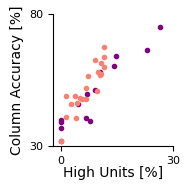

In [311]:
fig, ax = plt.subplots(1,1,figsize=(2,2))
for subject in subjects:
    nsites = len(lda_results[subject][align_event]['pseudopopulations']['column_scores'])
    _, pos_idx = np.unique(pop_results[subject][align_event]['unit_pos'], return_index=True, axis=0)
    unique_pos = pop_results[subject][align_event]['unit_pos'][pos_idx,:]
    high_mod_unit_pos = pop_results[subject][align_event]['unit_pos'][lda_results[subject][align_event]['single_ch_decoding_all'] >= pop_results[subject][align_event]['low_v_high']['high_dec_thresh'],:]
    nunits_per_pos = np.zeros(unique_pos.shape[0])*np.nan
    total_units_per_pos = np.zeros(unique_pos.shape[0])*np.nan
    
    for ipos in range(unique_pos.shape[0]):
        nunits_per_pos[ipos] = np.sum(np.logical_and(high_mod_unit_pos[:,0] == unique_pos[ipos,0], high_mod_unit_pos[:,1] == unique_pos[ipos,1]))
        total_units_per_pos[ipos] = np.sum(np.logical_and(pop_results[subject][align_event]['unit_pos'][:,0] == unique_pos[ipos,0], pop_results[subject][align_event]['unit_pos'][:,1] == unique_pos[ipos,1]))
    
    high_unit_prop = (nunits_per_pos/total_units_per_pos)*100
    enough_unit_mask = total_units_per_pos >= analysis_params['nunits_column']
    site_decoding = np.array([100*np.mean(lda_results[subject][align_event]['pseudopopulations']['column_scores'][isite]) for isite in range(nsites)])
    ax.plot(high_unit_prop[enough_unit_mask], site_decoding[enough_unit_mask], '.', color=vis_params['colors'][subject])
    ax.set_xlabel('High Units [%]', labelpad=0), ax.set_ylabel('Column Accuracy [%]')
    ax.set_xlim([-2,30]), ax.set_ylim([30,80])
    ax.set_xticks([0,30]), ax.set_yticks([30,80])
    fig.tight_layout()
    aopy.visualization.savefig(save_paths['figure'][4], f'high_unit_vs_column_acc_site.svg')

# Figure 5 Plots

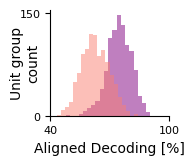

In [596]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,1,figsize=(2,1.75))
for subject in subjects:
    ax.hist(100*pop_results[subject][align_event]['random']['across_acc_La'], bins=20, color=vis_params['colors'][subject], alpha=0.5)
ax.set_xlim([40,100]), ax.set_xlabel('Aligned Decoding [%]')
ax.set_xticks([40,100]), ax.set_yticks([0,150]), ax.set_ylabel('Unit group\ncount', labelpad=-15)
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][5], f'random_units_dist.svg')

In [395]:
cb_min5, cb_max5 = 0.2, 1

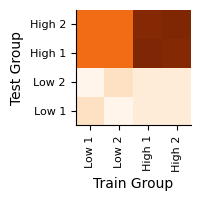

In [598]:
subject = 'affi'
fig, ax = plt.subplots(1,1,figsize=(1.5,1.5))
labels = pop_results[subject][align_event]['low_v_high']['Ln_split_labels']
im1 = ax.pcolor(np.arange(len(labels)), np.arange(len(labels)),np.mean(pop_results[subject][align_event]['low_v_high']['aligned_decoding'], axis=2).T, cmap='Oranges')
ax.set_xlabel('Train Group'), ax.set_ylabel('Test Group')
ax.set_xticks(np.arange(len(labels)), labels, rotation=90),ax.set_yticks(np.arange(len(labels)), labels, rotation=0)
ax.set_aspect('equal')
aopy.visualization.savefig(save_paths['figure'][5], f"aligned_decoding_high_low_heatmap.svg")

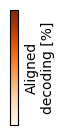

In [603]:
import matplotlib as mpl
cmap = mpl.cm.Oranges
norm = mpl.colors.Normalize(vmin=cb_min5, vmax=cb_max5)

fig, ax = plt.subplots(figsize=(0.1, 1.5))  # Adjust size as needed
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('Aligned\ndecoding [%]', labelpad=5)
cb.set_ticks([ ])
aopy.visualization.savefig(save_paths['figure'][5], f"aligned_decoding_high_low_colorbar.svg")

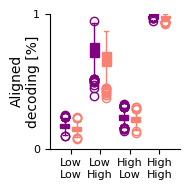

In [612]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,1,figsize=(2,2))

xpos = np.array([0, 1,2,3])
# colors= ['C0', 'C1']
for isubject, subject in enumerate(subjects):
    # subject = 'affi'
    plot_list = []
    plot_list.append(pop_results[subject][align_event]['low_v_high']['aligned_decoding'][0,1,:].flatten()) # low vs. Low
    plot_list.append(pop_results[subject][align_event]['low_v_high']['aligned_decoding'][[0,1],[2,3],:].flatten()) # low vs. High
    plot_list.append(pop_results[subject][align_event]['low_v_high']['aligned_decoding'][[2,3],[0,1],:].flatten()) # low vs. High
    plot_list.append(pop_results[subject][align_event]['low_v_high']['aligned_decoding'][2,3,:].flatten()) # high vs. high
    aopy.visualization.plot_boxplots(plot_list, xpos+(isubject*0.4), trendline=False, facecolor=vis_params['colors'][subject], linecolor=vis_params['colors'][subject], ax=ax, box_width=0.3, label_xticks=False)
ax.set_ylabel('Aligned\ndecoding [%]', labelpad=-5), ax.set_ylim(0,1)
ax.set_xticks([0.2, 1.2, 2.2, 3.2], ['Low\nLow', 'Low\nHigh','High\nLow', 'High\nHigh'])
ax.set_yticks(ax.get_ylim())
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][5], f'aligned_decoding_high_low_boxplot.svg')

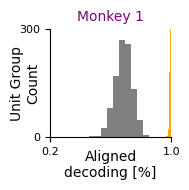

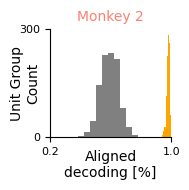

In [613]:
for isubject, subject in enumerate(subjects):
    # subject='affi'
    fig, ax = plt.subplots(1,1,figsize=(2,2))
    ax.hist(pop_results[subject][align_event]['any_v_high']['aligned_decoding'][1,0,:].flatten(), color='Gray')
    ax.hist(pop_results[subject][align_event]['low_v_high']['aligned_decoding'][3,2,:].flatten(), color='Orange')
    ax.set_xlabel('Aligned\ndecoding [%]', labelpad=-5), ax.set_xlim(.2, 1)
    ax.set_xticks(ax.get_xlim())
    ax.set_ylabel('Unit Group\nCount', labelpad=-15), ax.set_ylim([0,300]), ax.set_yticks([0,300])
    ax.set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])

    fig.tight_layout()
    aopy.visualization.savefig(save_paths['figure'][5], f'aligned_decoding_high_any_hist_{subject}.svg')

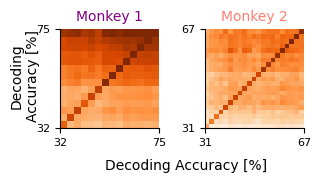

In [440]:
# align_event = align_events[-1]
fig, ax = plt.subplots(1,2, figsize=(3.5,2.5))
for isubject, subject in enumerate(subjects):
    nsites = pop_results[subject][align_event]['column']['aligned_decoding_acc_ordered'].shape[0]
    im = ax[isubject].pcolor(pop_results[subject][align_event]['column']['aligned_decoding_acc_ordered'].T, cmap='Oranges')
    im.set_clim(0.2,0.7)
    ax[isubject].set_xticks((0,nsites), (int(np.min(pop_results[subject][align_event]['column']['acc_ordered'])), int(np.max(pop_results[subject][align_event]['column']['acc_ordered']))))
    ax[isubject].set_yticks((0,nsites), (int(np.min(pop_results[subject][align_event]['column']['acc_ordered'])), int(np.max(pop_results[subject][align_event]['column']['acc_ordered']))))
    # ax[isubject].set_xlabel('Decoding\nAccuracy [%]', labelpad=-5), ax[isubject].set_ylabel('Decoding\nAccuracy [%]', labelpad=-2)
    ax[isubject].set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])
    ax[isubject].set_aspect('equal')
    
fig.supxlabel('Decoding Accuracy [%]', x=0.6, y=0.18, fontsize=vis_params['paper_settings']['axes.labelsize']), fig.supylabel('Decoding\nAccuracy [%]', x=0.14, y=0.57, ha='center', va='center', fontsize=vis_params['paper_settings']['axes.labelsize']) 
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][5], f'aligned_decoding_column_heatmap.svg')

In [615]:
site_aligned_decoding[-1]

0.6789416666666667

/tmp/ipykernel_465959/1260682791.py:11: UserWarning: Adding colorbar to a different Figure <Figure size 200x200 with 69 Axes> than <Figure size 350x200 with 2 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(ad_map)
/tmp/ipykernel_465959/1260682791.py:11: UserWarning: Adding colorbar to a different Figure <Figure size 200x200 with 70 Axes> than <Figure size 350x200 with 2 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(ad_map)


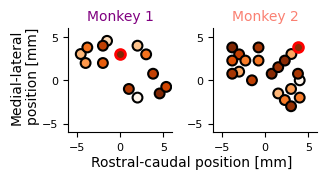

In [439]:
fig, ax = plt.subplots(1,2,figsize=(3.5,2))
for isubject, subject in enumerate(subjects):   
    site_aligned_decoding = pop_results[subject][align_event]['column']['aligned_decoding_acc_ordered'][:,-1]
    im = ax[isubject].scatter(pop_results[subject][align_event]['column']['rc_order'][:-1], pop_results[subject][align_event]['column']['ml_order'][:-1], s=50, c=site_aligned_decoding[:-1], cmap='Oranges', edgecolor='black', linewidths=1.5)
    im = ax[isubject].scatter(pop_results[subject][align_event]['column']['rc_order'][-1], pop_results[subject][align_event]['column']['ml_order'][-1], s=50, c=site_aligned_decoding[-1], cmap='Oranges', edgecolor='red', linewidths=2)
    im.set_clim([.2, 0.7])
    ax[isubject].set(xlim=(-6,6), ylim=(-6,6))
    ax[isubject].set_aspect('equal')
    ax[isubject].set_xticks([-5,0,5]), ax[isubject].set_yticks([-5,0,5])
    ax[isubject].set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])
    cb = plt.colorbar(ad_map)
    cb.set_label('Aligned decoding [%]',labelpad=-5)

fig.supxlabel('Rostral-caudal position [mm]', x=0.6, y=0.13, fontsize=vis_params['paper_settings']['axes.labelsize'])
fig.supylabel('Medial-lateral\nposition [mm]', x=0.08, y=0.6, va='center', fontsize=vis_params['paper_settings']['axes.labelsize'])     
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][5], f'aligned_decoding_1site_2dspatial.svg')

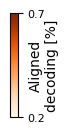

In [622]:
import matplotlib as mpl
cmap = mpl.cm.Oranges
norm = mpl.colors.Normalize(vmin=0.2, vmax=0.7)

fig, ax = plt.subplots(figsize=(0.1, 1.35))  # Adjust size as needed
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label('Aligned\ndecoding [%]', labelpad=-12)
cb.set_ticks([0.2, 0.7])
aopy.visualization.savefig(save_paths['figure'][5], f"aligned_decoding_site_colorbar.svg")

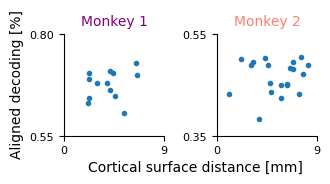

In [629]:
fig, ax = plt.subplots(1,2,figsize=(3.5,2))
for isubject, subject in enumerate(subjects): 
    nsites = pop_results[subject][align_event]['column']['aligned_decoding_acc_ordered'].shape[0]
    site_aligned_decoding = pop_results[subject][align_event]['column']['aligned_decoding_acc_ordered'][:,-1]
    ref_site_location = np.array([pop_results[subject][align_event]['column']['rc_order'][-1], pop_results[subject][align_event]['column']['ml_order'][-1]])
    surface_distance = [np.sqrt((ref_site_location[0] - pop_results[subject][align_event]['column']['rc_order'][isite])**2 + (ref_site_location[1] - pop_results[subject][align_event]['column']['ml_order'][isite])**2) for isite in range(nsites)]
    im = ax[isubject].plot(surface_distance[:-1], site_aligned_decoding[:-1], '.')

    if subject == 'affi':
        ax[isubject].set(ylim=(0.35,0.55))
    elif subject == 'beignet':
        ax[isubject].set(ylim=(0.55,0.8))
    ax[isubject].set(xlim=(0,9))
    ax[isubject].set_xticks(ax[isubject].get_xlim()), ax[isubject].set_yticks(ax[isubject].get_ylim())
    ax[isubject].set_title(f"Monkey {isubject+1}", color=vis_params['colors'][subject])
fig.supxlabel('Cortical surface distance [mm]', x=0.6, y=0.13, fontsize=vis_params['paper_settings']['axes.labelsize'])
fig.supylabel('Aligned decoding [%]', x=0.07, y=0.58,fontsize=vis_params['paper_settings']['axes.labelsize'])
fig.tight_layout()
aopy.visualization.savefig(save_paths['figure'][5], f'aligned_decoding_1site_1dspatial.svg')